## For an analysis between different dataframes, where for example inconsistencies might arise, look at merges.ipynb

### Import modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [2]:
reservoir_path = PATHS['pre_EDA'] / 'reservoir_for_EDA.csv'
reservoir_pd = pd.read_csv(reservoir_path)
reservoir_pd.head()

,id,scope,name,capacity,electric_flag
0,1,guadalquivir,brena,103.0,0
1,3,guadalquivir,fernandina,247.0,0
2,5,guadalquivir,puebla cazalla,87.0,0
3,6,guadalquivir,pedro marin,19.0,0
4,9,cuenca mediterranea andaluza,vinuela,170.0,0


### Study the most repeated scopes

<Axes: ylabel='scope'>

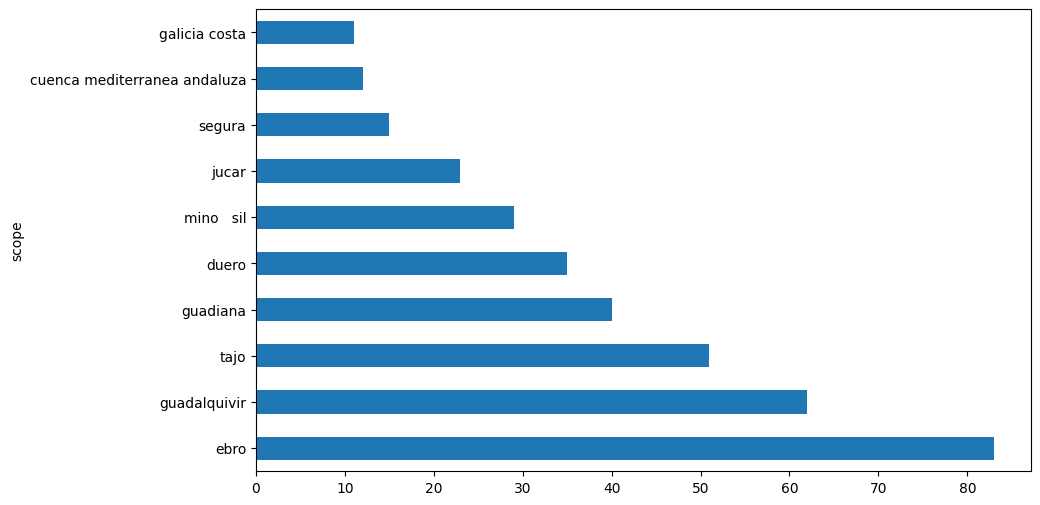

In [4]:
reservoir_pd['scope'].value_counts().head(10).plot(kind='barh', figsize=(10, 6))

### Boxplot of capacities

- Statistics:

In [8]:
reservoir_pd['capacity'].describe()

count     400.00000
mean      146.42000
std       341.76952
min         4.00000
25%        14.00000
50%        38.00000
75%       122.25000
max      3219.00000
Name: capacity, dtype: float64

- Graphic:

<Axes: >

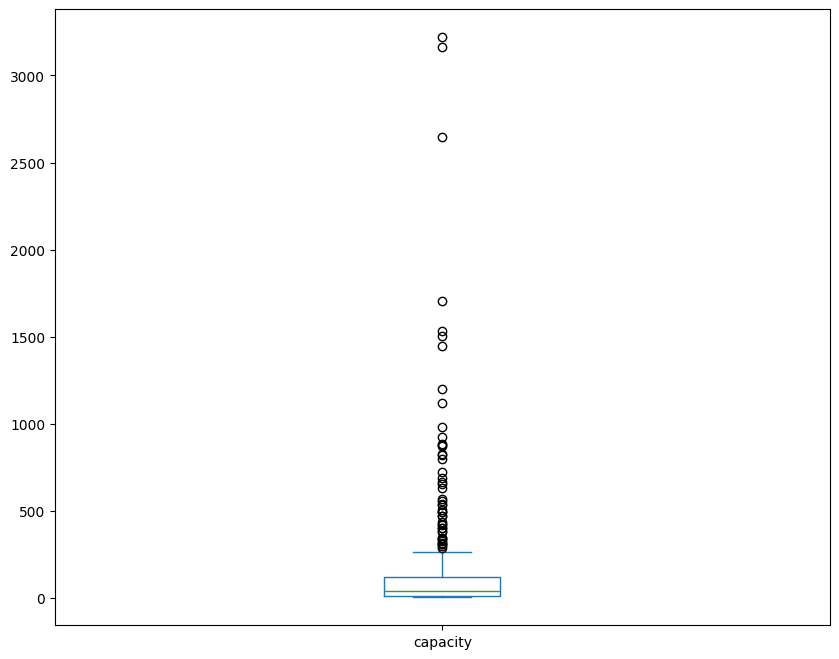

In [7]:
reservoir_pd['capacity'].plot(kind='box', figsize=(10, 8))


### Amount of electric reservoirs

C:\Users\usuario\AppData\Local\Temp\ipykernel_28252\3494763062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


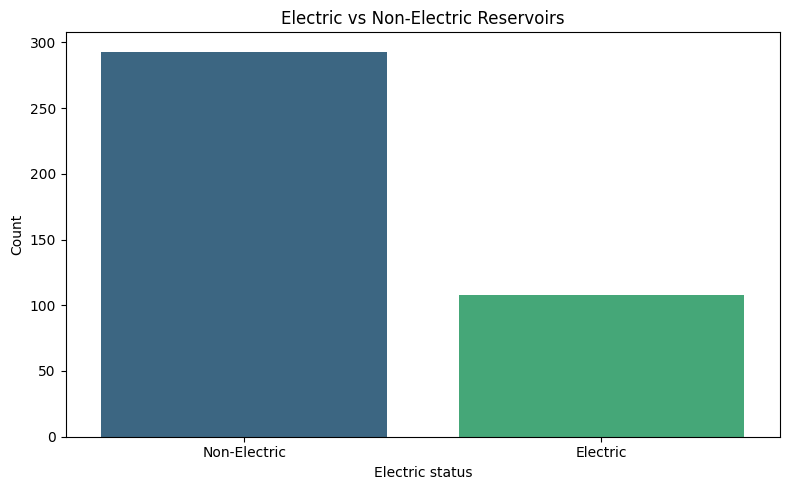

In [20]:
counts = reservoir_pd['electric_flag'].map({0: 'Non-Electric', 1: 'Electric'}).value_counts()

plt.figure(figsize=(8,5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


plt.xlabel('Electric status')
plt.ylabel('Count')
plt.title('Electric vs Non-Electric Reservoirs')
plt.tight_layout()
plt.show()

### Studying Missing Values

In [21]:
reservoir_pd.isnull().sum()

id               0
scope            0
name             0
capacity         1
electric_flag    0
dtype: int64

As there is only one capacity missing value, it could be easily ignored, but we will impute the maximum storage registered at its water dataframe